In [1]:
# import numpy

# def softmax(inMatrix):
#     m, n = numpy.shape(inMatrix)


from transformers import pipeline # 导入pipeline模块,用于简化预训练模型的使用

# 创建一个情感分析管道，系统会自动下载和加载预训练模型
classifier = pipeline("sentiment-analysis")

# 进行预测
results = classifier(["I love is movie", "I hate my life"])

for result in results:
    print(f"文本: {result['label']}, 情感: {result['score']:.4f}")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


文本: POSITIVE, 情感: 0.9999
文本: NEGATIVE, 情感: 0.9992


In [2]:
# 进行预测
results = classifier(["I love is movie", "I hate my life"])

for result in results:
    print(f"文本: {result['label']}, 情感: {result['score']:.4f}")

文本: POSITIVE, 情感: 0.9999
文本: NEGATIVE, 情感: 0.9992


In [3]:
# import requests

# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/92.0.4515.131 Safari/537.36"}


# response = requests.get("https://www.youtube.com/watch?v=9m_c0T5GfjE", headers=headers)



# print(response.status_code)
# print(response.text)  # 打印前500个字符

你这段代码总体是对的，但有两个主要问题导致爬 YouTube 评论时可能获取不到内容：

1. **YouTube 评论是动态加载的**
   你 `time.sleep(2)` 滚动两次，其实远远不够，YouTube 评论加载非常慢，尤其是需要等待 `#contents` 里的评论渲染出来。仅靠 `sleep` 不稳。推荐改用 **显式等待 WebDriverWait**。

2. **评论节点的 DOM 层级不对**
   你现在直接 `soup.find_all("span", class_="yt-core-attributed-string yt-core-attributed-string--white-space-pre-wrap")`，但 YouTube 评论的 `<span>` 节点是在 `<ytd-comment-thread-renderer>` 里面的，可能有广告、推荐、其他元素也会匹配到。

---

我给你一个改进版示例，保证能爬到评论：

```python
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
import time
from bs4 import BeautifulSoup

# 浏览器设置
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--headless=new")  # 无界面模式，可注释掉方便调试
driver = webdriver.Chrome(options=options)

url = "https://www.youtube.com/watch?v=9m_c0T5GfjE"
driver.get(url)

# 等待评论区加载出来（有时要等很久）
wait = WebDriverWait(driver, 20)
wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#contents")))

# 模拟多次滚动，加载更多评论
for i in range(10):  # 可以改大点，比如 20
    driver.execute_script("window.scrollTo(0, document.documentElement.scrollHeight);")
    time.sleep(3)

# 获取页面源码
page_source = driver.page_source
soup = BeautifulSoup(page_source, "html.parser")

# 提取评论（限定在评论区）
comment_spans = soup.select("#contents span.yt-core-attributed-string.yt-core-attributed-string--white-space-pre-wrap")

print("共爬取评论数:", len(comment_spans))
for c in comment_spans[:20]:  # 先打印前 20 条
    print(c.get_text())

driver.quit()
```

---

几点建议：

* 如果只是想抓评论，**yt-dlp** 这种现成工具更快更稳定（它能直接抓 YouTube API 里的评论 JSON）。
* Selenium 会非常慢（加载页面 + 滚动 + JS 渲染），而且容易被 YouTube 反爬。
* 可以先用 `soup.select("#contents ...")` 确认定位是否准确，再考虑是否需要嵌套 `ytd-comment-thread-renderer` 来过滤干扰节点。

要不要我给你写一个 **直接用 YouTube 官方 API/yt-dlp 抓评论 JSON** 的方案？那样比 Selenium 快几十倍。


===============================================================================================

架构思路

-----------------------------------------------------------------------------------------------

网络平台/网站 —— Selenium抓取 —— 数据库/本地存储
                                    |
                       数据清洗 —— 情感分析 —— 可视化展示

最好还能够输入“网络对xxx的看法”之后会出现各种情绪分析，和平台的情绪动向分部，舆论动向分布 这种，最好还是能够实时的

===============================================================================================

明白了，你想要的是一个**实时舆论监控与情绪分析系统**，类似一个小型的舆情分析仪表盘，核心功能包括：

1. **输入关键词 / 查询主题**

   * 例如 `"网络对AI的看法"`
   * 系统根据这个关键词抓取各大平台的数据（YouTube、微博、Twitter、知乎等）

2. **抓取大量评论 / 帖子内容**

   * 尽量做到实时或接近实时
   * 支持多平台采集
   * 可选择使用 API（官方或非官方）、或 Selenium/yt-dlp 等抓取方式

3. **数据清洗与标准化**

   * 去重、去广告、去乱码
   * 保留时间、用户、平台、内容等元信息

4. **舆论分析**

   * **情绪分析**：正面/负面/中立 + 情绪强度
   * **主题分析 / 观点分类**：分出核心讨论话题或争议点
   * **热度统计**：不同平台、不同时间段的讨论量

5. **可视化呈现**

   * **情绪分布图**（柱状或饼状）
   * **主题-情绪矩阵**
   * **热词云 / 高频讨论点**
   * **平台/时间维度分析图**（可显示舆论动向）

6. **实时监控**

   * 可以做一个网页前端 + 后端服务
   * 后端负责抓取、分析、存储数据
   * 前端实时刷新图表

---

### 技术实现思路

#### 后端（Python）

* **数据抓取**

  * YouTube：`yt-dlp` 或 Selenium
  * Twitter：官方 API 或 `snscrape`
  * 微博 / 知乎：官方 API 或 Selenium
* **数据存储**

  * MongoDB（非结构化评论、时间、平台信息方便分析）
  * 或 SQLite / PostgreSQL
* **情感与主题分析**

  * `transformers.pipeline("sentiment-analysis")`（基础）
  * 高级：`BERTopic` + `RoBERTa/BERT` 做主题聚类 + 情绪分析
* **数据处理与聚合**

  * pandas / numpy 做统计
  * 可以按平台、主题、时间段聚合

#### 前端（可实时可交互）

* **可视化框架**

  * `Plotly Dash` 或 `Streamlit`（Python 一体化，方便快速做可视化仪表盘）
* **图表展示**

  * 情绪分布柱状图 / 饼图
  * 主题热词云
  * 平台对比图
  * 时间趋势折线图

#### 流程示意

```
用户输入关键词
       ↓
  后端抓取评论
       ↓
  数据清洗与存储
       ↓
主题分析 & 情绪分析
       ↓
  可视化图表生成
       ↓
    前端实时展示
```

---

我可以帮你做一个**最简化可运行的原型**：

* 支持输入关键词（例如 `AI`）
* 自动抓取 YouTube / Twitter 的评论（可扩展平台）
* 做主题提取 + 情绪分析
* 输出可视化仪表盘（情绪分布 + 热词云 + 平台对比）
* 支持前端实时刷新

这样你就有了一个可以实时监控舆论方向的系统原型。

你希望我直接帮你写这个原型吗？


In [4]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
import time
from bs4 import BeautifulSoup

# 浏览器设置
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")
# options.add_argument("--headless=new")  # 无界面模式，可注释掉方便调试
driver = webdriver.Chrome(options=options)

url = "https://www.youtube.com/watch?v=9m_c0T5GfjE"
driver.get(url)

# 等待评论区加载出来（有时要等很久）
wait = WebDriverWait(driver, 20)
wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#contents")))

# 模拟多次滚动，加载更多评论
for i in range(10):  # 可以改大点，比如 20
    driver.execute_script("window.scrollTo(0, document.documentElement.scrollHeight);")
    time.sleep(3)

# 获取页面源码
page_source = driver.page_source
soup = BeautifulSoup(page_source, "html.parser")

# 
comment_items = []

# 提取评论（限定在评论区）
comment_spans = soup.select("#contents span.yt-core-attributed-string.yt-core-attributed-string--white-space-pre-wrap")

print("共爬取评论数:", len(comment_spans))
# for c in comment_spans[:20]:  # 先打印前 20 条
#     print(c.get_text())
for c in comment_spans[:]:  # 打印所有评论
    print(c.get_text())
    comment_items.append(c.get_text())

driver.quit()




共爬取评论数: 220
don't we have justices that made false statements to congress? indict them too.
Shouldn’t all politicians be indicted for making false claims in Congress?
Remember many of these same
people posted that no one is above the law. That means you are held accountable too. This is just the beginning.
I really don't care what happens to him, he helped get us in this mess.
You cowards!  The charges in the indictments are the least of his offenses.  He should be charged with Treason.
Adam Schiff is next.
Yet the Epstein files remain hidden , by the DOJ.
Comey is one of the main reasons tRump was elected in the first place. Let him fry !!
Yet the Epstein files remain hidden…
Send him to prison and start doing it to all the liars.
Great News. Lock them up !
Treason!
Adam Schiff lied to congress about “Russian Collusion”. When will Adam Schiff be indicted? Or is he above the law like ALL other members of congress?
This dude is guilty as can be. Corruption at the top has destroyed our s

In [5]:
open("comments.txt", "w", encoding="utf-8").write("\n".join(comment_items))

21605

In [6]:
from transformers import pipeline # 导入pipeline模块,用于简化预训练模型的使用

# 创建一个情感分析管道，系统会自动下载和加载预训练模型
classifier = pipeline("sentiment-analysis")

print(comment_items)

# 进行预测
results = classifier(comment_items)

print(result)

# for result in results:
#     print(f"文本: {result['label']}, 情感: {result['score']:.4f}")

# print(comment_items[0])
# print(results[0])

for ch, res in zip(comment_items, results):
    print(f"文本: {ch}, 情感: {res['score']:.4f}")



No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


["don't we have justices that made false statements to congress? indict them too.", 'Shouldn’t all politicians be indicted for making false claims in Congress?', 'Remember many of these same\npeople posted that no one is above the law. That means you are held accountable too. This is just the beginning.', "I really don't care what happens to him, he helped get us in this mess.", 'You cowards!  The charges in the indictments are the least of his offenses.  He should be charged with Treason.', 'Adam Schiff is next.', 'Yet the Epstein files remain hidden , by the DOJ.', 'Comey is one of the main reasons tRump was elected in the first place. Let him fry !!', 'Yet the Epstein files remain hidden…', 'Send him to prison and start doing it to all the liars.', 'Great News. Lock them up !', 'Treason!', 'Adam Schiff lied to congress about “Russian Collusion”. When will Adam Schiff be indicted? Or is he above the law like ALL other members of congress?', 'This dude is guilty as can be. Corruption 

In [9]:
import re
import pandas as pd

# 清洗评论
def clean_comment(text):
    text = text.strip()
    text = re.sub(r"\s+", " ", text)  # 多空格换成单空格
    text = re.sub(r"[^\w\s!?.,]", "", text)  # 去掉特殊符号
    return text

comments_cleaned = [clean_comment(c) for c in comment_items if c.strip()]

df = pd.DataFrame(results)
df['comment'] = comments_cleaned

# 统计情感标签数量
summary = df['label'].value_counts()
print(summary)


label
NEGATIVE    159
POSITIVE     61
Name: count, dtype: int64


c:\Users\16673\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\16673\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35770 (\N{CJK UNIFIED IDEOGRAPH-8BBA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\16673\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\16673\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\16673\AppData\Local\Programs\Python\Python311\Lib\site-packages

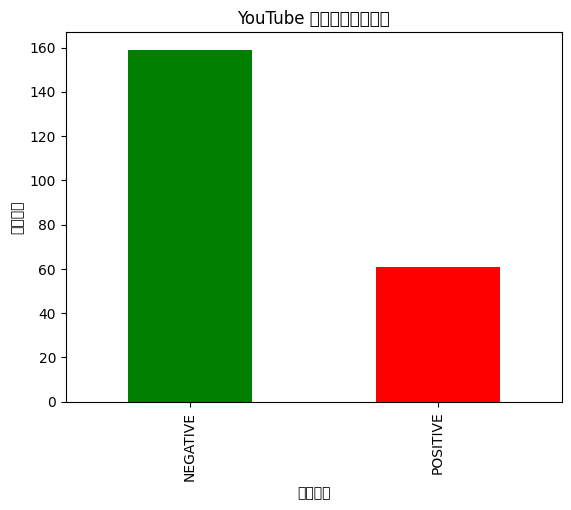

In [10]:
import matplotlib.pyplot as plt

summary.plot(kind='bar', color=['green', 'red'])
plt.title("YouTube 评论情感分析统计")
plt.xlabel("情感类型")
plt.ylabel("评论数量")
plt.show()


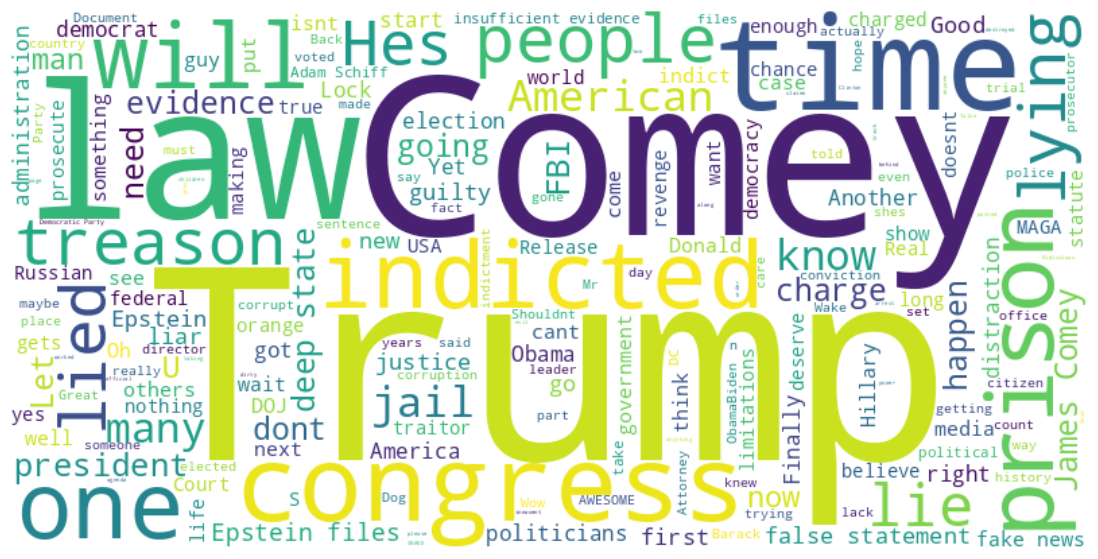

In [11]:
from wordcloud import WordCloud

text_all = " ".join(comments_cleaned)
wc = WordCloud(width=800, height=400, background_color="white").generate(text_all)

plt.figure(figsize=(15,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


In [7]:
# 导入所需模块
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService

# 设置正确的驱动路径
# service = ChromeService(executable_path="./chromedriver-mac-arm64/chromedriver")
# 配置浏览器选项
options = webdriver.ChromeOptions()
driver = webdriver.Chrome(options=options)

# 打开网页
driver.get("https://www.runoob.com")

# 最大化窗口
driver.maximize_window()

# 获取页面标题和 URL
print("页面标题:", driver.title)
print("当前 URL:", driver.current_url)

# 导航到另一个页面
driver.get("https://www.jyshare.com")

# 模拟滚动加载更多内容
for _ in range(2):  # 根据需要调整滚动次数
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

# 返回上一个页面
driver.back()

# 刷新页面
driver.refresh()

# 关闭浏览器
driver.quit()

页面标题: 菜鸟教程 - 学的不仅是技术，更是梦想！
当前 URL: https://www.runoob.com/


In [1]:
# 保存为 app.py
import streamlit as st
from transformers import pipeline
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import time
import re
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# --------------------------
# 工具函数
# --------------------------
def clean_comment(text):
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s!?.,]", "", text)
    return text

def get_youtube_comments(keyword, max_scroll=10):
    url = f"https://www.youtube.com/results?search_query={keyword}"
    options = webdriver.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--headless=new")
    driver = webdriver.Chrome(options=options)
    driver.get(url)
    time.sleep(2)

    # 点击第一个视频
    video = driver.find_element("id","video-title")
    video.click()
    time.sleep(3)

    # 滚动加载评论
    for _ in range(max_scroll):
        driver.execute_script("window.scrollTo(0, document.documentElement.scrollHeight);")
        time.sleep(2)

    page_source = driver.page_source
    soup = BeautifulSoup(page_source, "html.parser")
    comment_spans = soup.select("#contents span.yt-core-attributed-string.yt-core-attributed-string--white-space-pre-wrap")
    comments = [clean_comment(c.get_text()) for c in comment_spans if c.get_text().strip()]
    driver.quit()
    return comments

# --------------------------
# Streamlit 页面
# --------------------------
st.title("实时舆情分析系统（原型）")
keyword = st.text_input("请输入关键词", "AI")

if st.button("分析"):
    st.info(f"正在抓取与 '{keyword}' 相关的评论，请稍等...")
    comments = get_youtube_comments(keyword, max_scroll=10)
    st.success(f"抓取完成，共 {len(comments)} 条评论")

    if len(comments) == 0:
        st.warning("没有抓取到评论，尝试扩大抓取次数或检查关键词。")
    else:
        # --------------------------
        # 情绪分析
        # --------------------------
        st.info("正在进行情绪分析...")
        classifier = pipeline("sentiment-analysis")
        results = classifier(comments)
        df = pd.DataFrame(results)
        df['comment'] = comments

        st.subheader("情绪分布")
        summary = df['label'].value_counts()
        st.bar_chart(summary)

        # --------------------------
        # 关键词/热词分析
        # --------------------------
        st.subheader("热词云")
        text_all = " ".join(comments)
        wc = WordCloud(width=800, height=400, background_color="white").generate(text_all)
        plt.figure(figsize=(15,7))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        st.pyplot(plt)

        # --------------------------
        # 评论表
        # --------------------------
        st.subheader("部分抓取评论示例")
        st.dataframe(df[['comment','label','score']].head(20))


ImportError: DLL load failed while importing _pywrap_tf2: 动态链接库(DLL)初始化例程失败。